In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

#jax.config.update('jax_platform_name', 'cpu')

# Set default device to CPU


from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE, VPSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

In [ ]:
prior = Normal(jnp.zeros((1,)), jnp.ones((1,))) 

In [ ]:

# VESDE 
T = 1.
T_min = 1e-2
sigma_min = 1e-1
sigma_max = 10.

thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VESDE(p0, sigma_min=sigma_min , sigma_max=sigma_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    return (1/scale * x).reshape(x.shape)

def weight_fn(t):
    #return jnp.clip(sde.diffusion(t, jnp.ones((1,1,1)))**2, 1e-4)
    return jnp.ones((1,1,1))

In [ ]:

# # VPSDE 
# T = 1.
# T_min = 1e-1
# beta_min = 0.01
# beta_max = 20.

# thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
# p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
# sde = VPSDE(p0, beta_min=beta_min , beta_max=beta_max)

# def output_scale_fn(t, x):
#     scale = sde.marginal_stddev(t, jnp.ones_like(x))
#     return (1/scale * x).reshape(x.shape)

# def weight_fn(t):
#     #return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-1
#     return jnp.ones((1,1,1))

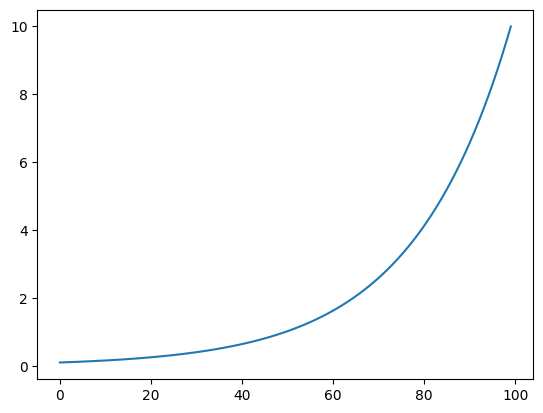

In [ ]:
plt.plot(sde.marginal_stddev(jnp.linspace(0., 1., 100), jnp.ones((100,1))))

In [ ]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 50
activation = jax.nn.gelu
num_hidden = 6
layer_norm = True

def score_net(a, theta, x_t0, x_t1):
    
    context = jnp.concatenate([x_t0, x_t1], axis=-1) 

    time_embedding = GaussianFourierEmbedding(128)(a[..., None])
    
    h1 = hk.Linear(hidden_dim//2)(context)
    h2 = hk.Linear(hidden_dim - hidden_dim//2)(theta)
    
    h = activation(jnp.concatenate([h1, h2], axis=-1))

    for _ in range(num_hidden - 1):
        h_new = hk.Linear(hidden_dim)(h)
        h_new += hk.Linear(hidden_dim)(time_embedding)
        h = activation(h_new)

        if layer_norm:
            h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

    out = hk.Linear(theta.shape[-1])(h)
    out = output_scale_fn(a, out)

    return out.reshape(theta.shape)


In [ ]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones((10,)), thetas[:10], jnp.ones((10, 1)), jnp.ones((10, 1))) # Initialize the parameters of the model

In [ ]:
sigma_x0 = 100.
def generate_data(key, n):
    key1, key2, key3 = jax.random.split(key, 3)
    
    theta_batch = jax.random.normal(key1, (n,1))
    x_t = jax.random.normal(key2, (n,1))*sigma_x0    
    x_t1 =  x_t + theta_batch + jax.random.normal(key3, (n,1)) 
    return theta_batch, x_t, x_t1


In [ ]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [ ]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [ ]:


def loss_fn(params, key, batch_size= 2048):

    rng_time, rng_data, rng_sample = jax.random.split(key, 3)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size,), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1, axis=-1)
    
    return loss


In [ ]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [ ]:

#optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adam(5e-4))
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [ ]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [ ]:
key = jrandom.PRNGKey(0)

In [ ]:
for _ in range(20):
    l = 0
    for i in range(2000):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 2000
    print(l)

1.6209964
1.4064422
1.394849
1.3898264
1.391373
1.3923142


KeyboardInterrupt: 

In [198]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [810]:

def true_marginal(a, x_t0, x_t1):
    a = jnp.atleast_1d(a)
    x_t0 = jnp.atleast_1d(x_t0)
    x_t1 = jnp.atleast_1d(x_t1)
    post_mean = 0.5*(x_t1 - x_t0)
    post_std = jnp.sqrt(0.5)
    diffusion_std = sde.marginal_stddev(a, jnp.ones_like(post_std))
    diffusion_mean = sde.marginal_mean(a, jnp.ones_like(post_mean))
    
    mean = diffusion_mean * post_mean
    std = jnp.sqrt(diffusion_std**2 + (diffusion_mean*post_std)**2)
    
    return mean, std

def true_marginal_prior(a):
    a = jnp.atleast_1d(a)
    prior_mean = jnp.zeros_like(a)
    prior_std = jnp.ones_like(a)
    diffusion_std = sde.marginal_stddev(a, jnp.ones_like(prior_std))
    diffusion_mean = sde.marginal_mean(a, jnp.ones_like(prior_mean))
    
    mean = diffusion_mean * prior_mean
    std = jnp.sqrt(diffusion_std**2 + (diffusion_mean*prior_std)**2)
    
    return mean, std

def true_marginal_prior_score(a):
    mean, std = true_marginal_prior(a)
    return jax.grad(lambda x: jax.scipy.stats.norm.logpdf(x, mean, std).sum())(a)

def product_of_gaussians(mean1, std1, mean2, std2):
    mean = (mean1 * std2**2 + mean2 * std1**2) / (std1**2 + std2**2)
    std = jnp.sqrt(1 / (1/std1**2 + 1/std2**2))
    return mean, std

def product_of_n_gaussians(means, stds):
    mean = jnp.sum(means / stds**2, axis=0) / jnp.sum(1 / stds**2, axis=0)
    std = jnp.sqrt(1 / jnp.sum(1 / stds**2, axis=0))
    return mean, std

def divide_gaussians(mean1, std1, mean2, std2):
    mean = (mean1 * std2**2 - mean2 * std1**2) / (std2**2 - std1**2)
    std = jnp.sqrt(1 / (1/std1**2 - 1/std2**2))
    return mean, std

def product_n_times_gaussian(mean, std, n):
    return mean * n, std * jnp.sqrt(n)

def approx_full_marginal(a, xs):
    xs_t0s = xs[:-1]
    xs_t1s = xs[1:]

    means, stds = jax.vmap(true_marginal,in_axes=(None,0,0))(a, xs_t0s, xs_t1s)
    mean_prior, std_prior = true_marginal_prior(a)
    means, stds = jax.vmap(divide_gaussians, in_axes=(0,0,None,None))(means, stds, mean_prior, std_prior)
    mean, std = product_of_n_gaussians(means, stds)
    mean, std = product_of_gaussians(mean, std, mean_prior, std_prior)
    return mean, std

def true_score(a, theta, x_t0, x_t1):
    mean, std = true_marginal(a, x_t0, x_t1)  
    score = jax.grad(lambda x: jax.scipy.stats.norm.logpdf(x, mean, std).sum())(theta)
    return score

def approx_full_score(a, theta, xs):
    xs_t0s = xs[:-1]
    xs_t1s = xs[1:]

    scores = jax.vmap(true_score, in_axes=(None,None,0,0))(a, theta, xs_t0s, xs_t1s)
    prior_score = true_marginal_prior_score(a)

    accumulated_score = jnp.sum(scores - prior_score, axis=0)
    out_score = accumulated_score  + prior_score

    return out_score

In [811]:
a = jnp.array([0.1])

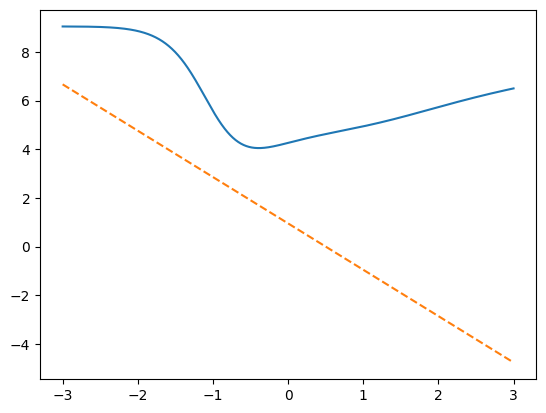

In [812]:
t = jnp.linspace(-3,3, 1000)
t = t.reshape(-1, 1)    
s = model_fn(params, a, t, jnp.zeros((1000,1)),  jnp.ones((1000,1)))
plt.plot(t, s)
plt.plot(t, jax.vmap(true_score, in_axes=(None,0,None,None))(a,t, 0.,1.0), "--")

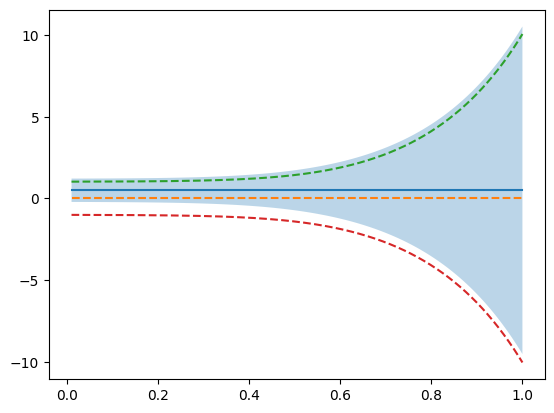

In [813]:
a = jnp.linspace(T_min, 1.0, 1000)
mean, stds = true_marginal(a, 0., 1.0)
m = sde.marginal_mean(a)
s = sde.marginal_stddev(a)
plt.plot(a, mean)
plt.fill_between(a, mean-stds, mean+stds, alpha=0.3)
plt.plot(a, m, "--")
plt.plot(a, m + s, "--")
plt.plot(a, m-s, "--")

In [814]:
true_marginal_prior(0.2)

(Array([0.], dtype=float32, weak_type=True),
 Array([1.031], dtype=float32, weak_type=True))

In [815]:
theta_o = jnp.array([-.5])

x_0 = jnp.array([0.])
xs = [x_0]
num_T = 10
for i in range(num_T):
    x_1 = x_0 + theta_o + jax.random.normal(jrandom.PRNGKey(i+2), (1,))
    x_0 = x_1
    xs.append(x_1)
    
x_o = jnp.array(xs)[:,0]

In [816]:
approx_full_score(0., theta_o, x_o) 

Array([6.486], dtype=float32)

In [817]:
m, s = approx_full_marginal(0.1, x_o)

In [818]:
jax.grad(lambda x: jax.scipy.stats.norm.logpdf(x, m, s).sum())(theta_o)

Array([1.91], dtype=float32)

ValueError: x and y must have same first dimension, but have shapes (1000,) and (1,)

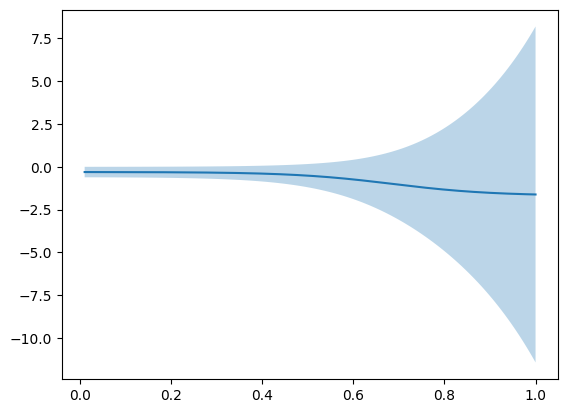

In [819]:
a = jnp.linspace(T_min, 1.0, 1000)

mean, stds = jax.vmap(approx_full_marginal, in_axes=(0,None))(a,x_o)
mean = mean.reshape(-1)
stds = stds.reshape(-1)

plt.plot(a, mean)
plt.fill_between(a, mean-stds, mean+stds, alpha=0.3)
plt.plot(a, m, "--")
plt.plot(a, m + s, "--")
plt.plot(a, m-s, "--")
plt.show()

In [710]:
approx_full_marginal(0, x_o)

(Array([-0.31], dtype=float32), Array([0.306], dtype=float32))

In [711]:
true_posterior(x_o)

Normal(loc: [-0.282], scale: [0.289])

In [712]:
theta = theta_o
t = jnp.array([0.1])

In [713]:
x_past = x_o[:-1, None]
x_future = x_o[1:,None]

In [248]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    #x1, x2 = jnp.split(x_o, 2)
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    increment_scores = model_fn(params, t, theta_batch, x_past, x_future)
    N = increment_scores.shape[0]
    std_t = sde.marginal_stddev(t)
    std_t_last = sde.marginal_stddev(jnp.array(T_min))
    #prior_score = (1-t)* std_t_last**2/std_t**2 * jax.grad(lambda x: prior.log_prob(x).sum())(theta) 
    prior_score = (1-t)* jax.grad(lambda x: prior.log_prob(x).sum())(theta)
    score = increment_scores.sum(axis=0) -  (N-1)*prior_score

    score = score.reshape(theta.shape)

    f =  sde.drift(t,theta) - sde.diffusion(t,theta)**2 * score
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,theta):
    #t = T - t
    b =  sde.diffusion(t,theta) 
    return b

In [249]:

end_std = jnp.squeeze(sde.marginal_stddev(jnp.ones(1)))
end_mean = jnp.squeeze(sde.marginal_mean(jnp.ones(1)))

def sample_fn(key, shape,x_o, time_steps=100):
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    Ts = x_o.shape[0] - 1
    x_T = jax.random.normal(key1, shape + (1,)) * end_std / Ts  + end_mean
    
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, x_o=x_o), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [310]:
def true_posterior(x_o):
    
    T = x_o.shape[0] 
    x_first = x_o[0, None]
    x_last = x_o[-1,None]
    
    mean_posterior = (x_last- x_first)/(T+1)
    std_posterior = 1/jnp.sqrt(T+1)
    return Normal(mean_posterior, std_posterior)

In [251]:
samples = sample_fn(jrandom.PRNGKey(0), (10000,), x_o)

In [252]:
l = jnp.linspace(-3, 3, 1000)
Z = jnp.exp(true_posterior(x_o).log_prob(l[:,None]).sum(-1))

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6831: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/root/miniconda3/envs/probjax/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6832: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

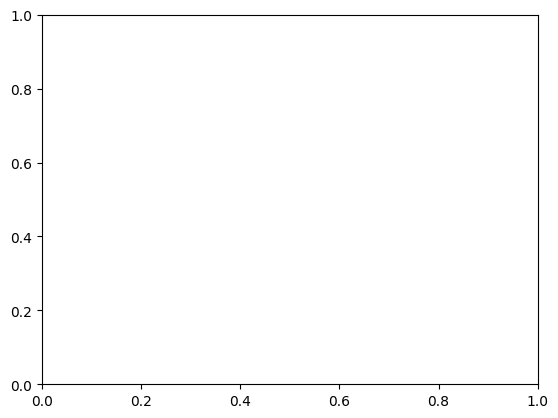

In [253]:
plt.hist(samples[:, -1,0], density=True, bins = 100)
_ = plt.plot(l,Z)
#plt.xlim(-3,3)